Notebook does the following: 
***
1. plots timeseries of sea ice (Sep and March) area change over time
2. plots scatter plots of sea ice area vs global temperature, and (for sup.) vs Arctic temp.

***
To add:
plotting maps of sea ice conc 

In [16]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
from nc_processing import grid_cell_areas
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})


from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, UKESM_ARISE_run_IDs, ens_mems_CE, colours, model_colors

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
import json
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [17]:
### get tas

## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')
ds_HiLLA_15_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')

## repeat for CESM
ds_HiLLA_13_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## repeat for E3SM
ds_HiLLA_13_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    print(model)
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        print(alt)
        data = HiLLA_tas[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_timeseries_tas = dict(zip(models, timeseries_dicts_models))

d
UKESM
13km
15km
CESM
13km
15km
E3SM
13km
15km


In [19]:
### repeat to get the SSP2-4.5 temp
DS_ssp245_tas_UK = weighted_annual_resample(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = weighted_annual_resample(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_CE, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})


ds_ssp245_tas_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = weighted_annual_resample(ds_ssp245_tas_E3, var='tas').sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')

SSP245_data = {'UKESM':DS_ssp245_tas_UK, 'CESM':DS_ssp245_tas_CE, 'E3SM':DS_ssp245_tas_E3}

## reduce SSP2-4.5 data to annually resampled timeseries
timeseries_dicts = []
for model in models:
    print(model)
    data = SSP245_data[model].load()
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
SSP245_timeseries_dict = dict(zip(models, timeseries_dicts))

UKESM
CESM
E3SM


In [31]:
### now repeat for sea ice

def SI_area_timeseries(ds, perc=True, lat_coord='y', lon_coord='x'):
    ds = ds.rename({lat_coord:'y', lon_coord:'x'})
    ds.load()
    tss = []
    for lat_band in [[-90, 0], [0, 90]]:
        ds_h = ds.sel(y=slice(lat_band[0], lat_band[1]))
        grid_areas = xr.DataArray(
                grid_cell_areas(ds_h.x, ds_h.y),
                dims=['y', 'x'],
                coords=[ds_h.y, ds_h.x]
                ).to_dataset(name='areas')
        SI_area_m2_ds = (ds_h['siconca']*grid_areas['areas']).to_dataset(name='si_area_Mkm2')
        SI_area_Mkm2_ts = SI_area_m2_ds.sum(dim=["x", "y"])*(10**-12)
        if perc==True:
            SI_area_Mkm2_ts = SI_area_Mkm2_ts*(10**-2)
        tss.append(SI_area_Mkm2_ts)
        ds.close()
    return {'SH':tss[0], 'NH':tss[1]}


## UKESM
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='siconc', table='SImon').sel(time=slice(None, '2069')).rename({'siconc':'siconca'})
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='siconc', table='SImon').sel(time=slice(None, '2069')).rename({'siconc':'siconca'})

## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Sea_ice_frac/case01_60NS_13km_MAMJ_6Tg_ICEFRAC.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'ICEFRAC':'siconca'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Sea_ice_frac/case04_60NS_15km_MAMJ_6Tg_ICEFRAC.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'ICEFRAC':'siconca'}).sel(time=slice(None, '2069'))

## repeat for E3SM
ds_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/ICEFRAC_regridded/ICEFRAC.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'ICEFRAC':'siconca'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/ICEFRAC_regridded/ICEFRAC.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'ICEFRAC':'siconca'}).sel(time=slice(None, '2069'))


## combine into a dict
HiLLA_siconca =  {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
                  'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
                  'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}


## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseriess = []
    for alt in HiLLA_altitudes:
        data = HiLLA_siconca[model][alt]
        timeseriess.append(SI_area_timeseries(data, perc=False,
                                lon_coord='longitude', lat_coord='latitude'))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseriess)))

HiLLA_timeseries_SIa = dict(zip(models, timeseries_dicts_models))

PermissionError: [Errno 13] Permission denied: '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/u-dm204dn587/SImon/siconc/u-dm204dn587_siconc.nc'

In [26]:
### repeat to get the SSP245 sea ice:
DS_ssp245_SI_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=ens_mems_arise_UK, 
                              table='SImon', grid='gr').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_SI_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], 
                              table='SImon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_SI_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/ICEFRAC/ICEFRAC.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'ICEFRAC':'siconca'})
ds_ssp245_SI_E3 = cut_incomplete_years(ds_ssp245_SI_E3).sel(time=slice('2015', '2069'))
DS_ssp245_SI_E3 = xr.concat([ds_ssp245_SI_E3], dim='Ensemble_member')
DS_ssp245_SI_E3 = (100*DS_ssp245_SI_E3.siconca).to_dataset(name='siconca') # frac defined as frac not percentage
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data_siconca = {'UKESM':DS_ssp245_SI_UK, 'CESM':DS_ssp245_SI_CE, 'E3SM':DS_ssp245_SI_E3}

## reduce SSP2-4.5 data to annually resampled timeseries
timeseriess = []
for model in models:
    print(model)
    data = SSP245_data_siconca[model].load()
    timeseriess.append(SI_area_timeseries(data, perc=True,
                       lon_coord='longitude', lat_coord='latitude'))
    
SSP245_timeseries_SIa = dict(zip(models, timeseriess))

UKESM
CESM
E3SM


In [27]:
matplotlib.rcParams.update({'font.size': 15})

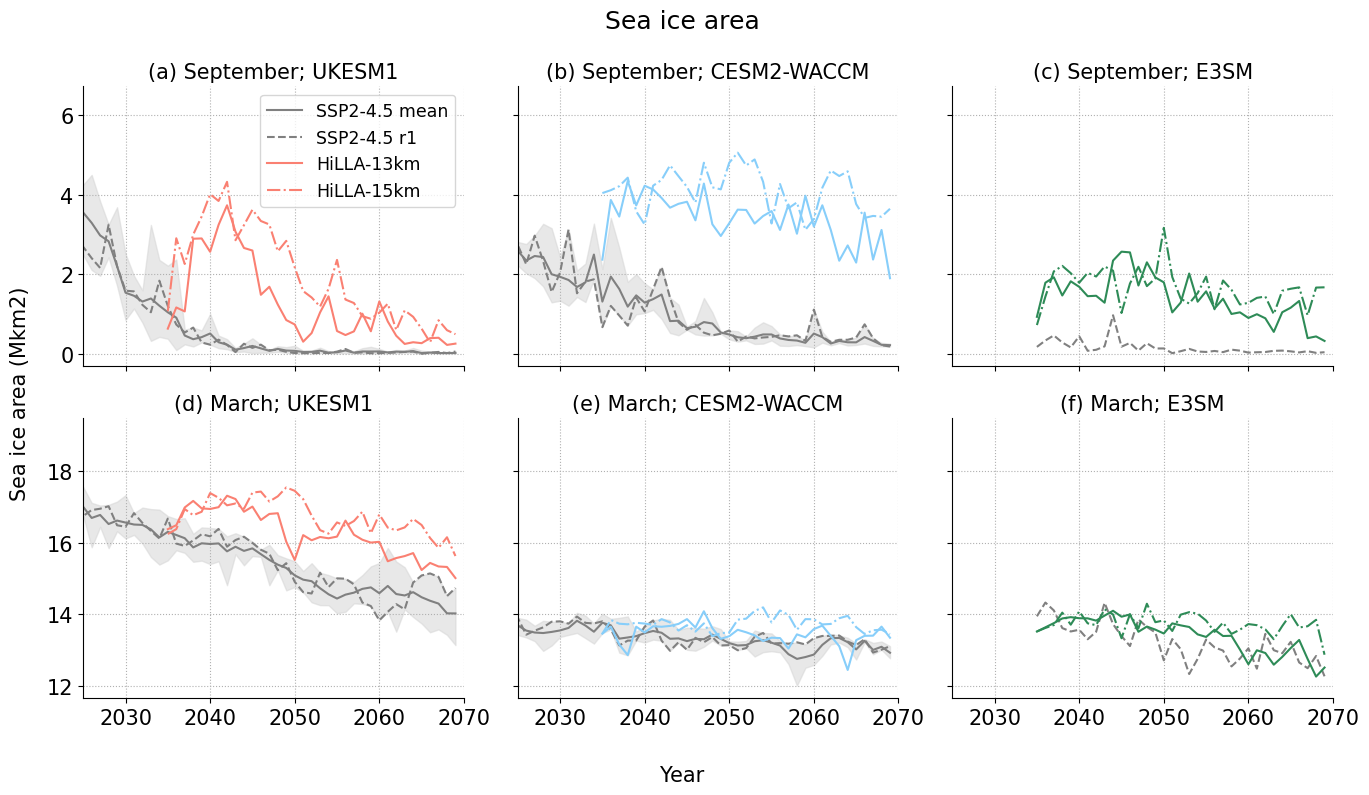

In [28]:
### Now plot

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}


j=0
hem = 'NH'
for model in models:
    i=0
    for month in [9, 3]:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_SIa[model][hem].si_area_Mkm2
        ts_ssp245 = ts_ssp245.where(ts_ssp245.time.dt.month==month, drop=True)
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member')), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                                ts_ssp245.min('Ensemble_member').values, 
                                ts_ssp245.max('Ensemble_member').values, 
                                color=colours['ssp245_light'], alpha=0.5)
            
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, ts_ssp245.isel(Ensemble_member=0), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')

        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_SIa[model][alt][hem]
            HiLLA = HiLLA.where(HiLLA.time.dt.month==month, drop=True)
            ax.plot(HiLLA.time.dt.year,(HiLLA.si_area_Mkm2),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if i==0:
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=1)
        
        i=i+1
    
        
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.suptitle('Sea ice area')
axs[0, 0].set_title('(a) September; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) September; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(c) September; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) March; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) March; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) March; E3SM', fontsize='medium')

fig.supylabel('Sea ice area (Mkm2)', fontsize='medium')
fig.supxlabel('Year', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/Sea_ice_area_evolution.jpg', dpi=350)

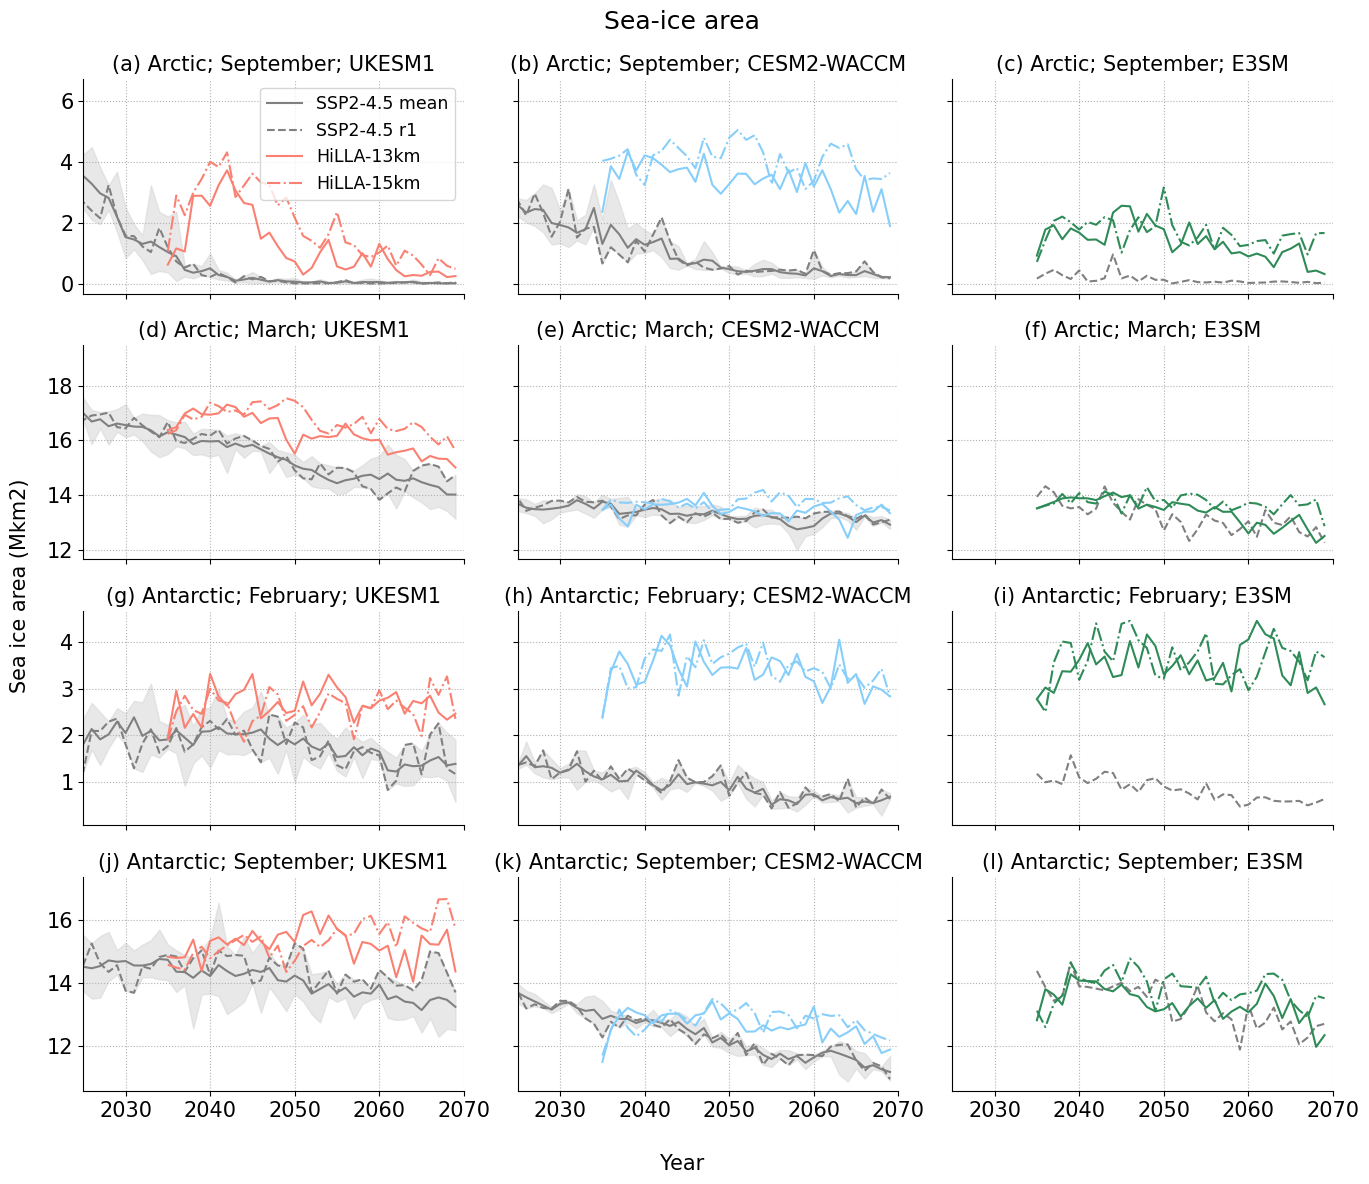

In [29]:
### v2 of the above - add SH and rearrange

### Now plot

fig, axs = plt.subplots(4, 3, figsize=(14, 12), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
months_hem_dict = {'NH':[9, 3], 'SH':[2, 9]}

j=0
hem = 'NH'
for model in models:
    i=0
    for hemisphere in ['NH', 'SH']:
        for month in months_hem_dict[hemisphere]:
            ax = axs[i, j]
            
            ts_ssp245 = SSP245_timeseries_SIa[model][hemisphere].si_area_Mkm2
            ts_ssp245 = ts_ssp245.where(ts_ssp245.time.dt.month==month, drop=True)
            
            if model in ['UKESM', 'CESM']:
                ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member')), c=colours['ssp245'], label='SSP2-4.5 mean')
                ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                                    ts_ssp245.min('Ensemble_member').values, 
                                    ts_ssp245.max('Ensemble_member').values, 
                                    color=colours['ssp245_light'], alpha=0.5)
                
            ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, ts_ssp245.isel(Ensemble_member=0), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
    
            for alt in HiLLA_altitudes:
                HiLLA = HiLLA_timeseries_SIa[model][alt][hemisphere]
                HiLLA = HiLLA.where(HiLLA.time.dt.month==month, drop=True)
                ax.plot(HiLLA.time.dt.year,(HiLLA.si_area_Mkm2),
                c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
                
            ax.grid(ls='dotted')
            if i==0:
                if model == 'UKESM':
                    ax.legend(fontsize='small', ncols=1)
            
            i=i+1
    
        
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.suptitle('Sea-ice area', fontsize='large')
axs[0, 0].set_title('(a) Arctic; September; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) Arctic; September; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(c) Arctic; September; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) Arctic; March; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) Arctic; March; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) Arctic; March; E3SM', fontsize='medium')
axs[2, 0].set_title('(g) Antarctic; February; UKESM1', fontsize='medium')
axs[2, 1].set_title('(h) Antarctic; February; CESM2-WACCM', fontsize='medium')
axs[2, 2].set_title('(i) Antarctic; February; E3SM', fontsize='medium')
axs[3, 0].set_title('(j) Antarctic; September; UKESM1', fontsize='medium')
axs[3, 1].set_title('(k) Antarctic; September; CESM2-WACCM', fontsize='medium')
axs[3, 2].set_title('(l) Antarctic; September; E3SM', fontsize='medium')

fig.supylabel('Sea ice area (Mkm2)', fontsize='medium')
fig.supxlabel('Year', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/Sea_ice_area_evolution_V2.jpg', dpi=350, bbox_inches='tight')

AttributeError: 'dict' object has no attribute 'si_area_Mkm2'

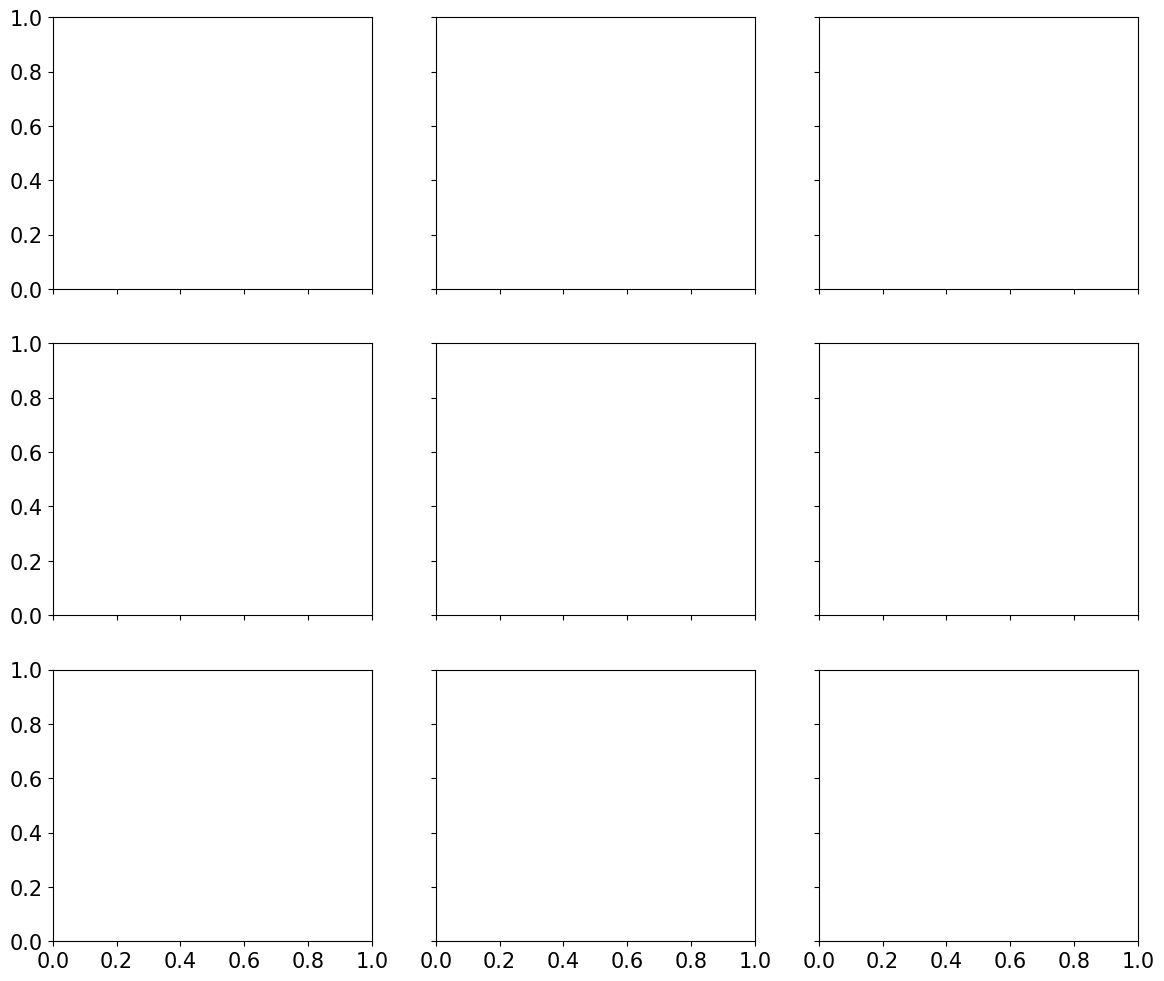

In [14]:
### Now plot

fig, axs = plt.subplots(3, 3, figsize=(14, 12), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}


j=0

for model in models:
    i=0
    for month in [9, 3]:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_SIa[model].si_area_Mkm2
        ts_ssp245 = ts_ssp245.where(ts_ssp245.time.dt.month==month, drop=True)
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member')), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                                ts_ssp245.min('Ensemble_member').values, 
                                ts_ssp245.max('Ensemble_member').values, 
                                color=colours['ssp245_light'], alpha=0.5)
            
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, ts_ssp245.isel(Ensemble_member=0), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')

        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_SIa[model][alt]
            HiLLA = HiLLA.where(HiLLA.time.dt.month==month, drop=True)
            ax.plot(HiLLA.time.dt.year,(HiLLA.si_area_Mkm2),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        
        if i==0:
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=1)
        
        i=i+1

    i=2
    ax = axs[i, j]
    ts_ssp245 = weighted_annual_resample(SSP245_timeseries_SIa[model], 'si_area_Mkm2').si_area_Mkm2
    
    if model in ['UKESM', 'CESM']:
        ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member')), c=colours['ssp245'], label='SSP2-4.5 mean')
        ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values, 
                            ts_ssp245.max('Ensemble_member').values, 
                            color=colours['ssp245_light'], alpha=0.5)
        
    ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, ts_ssp245.isel(Ensemble_member=0), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
    
    for alt in HiLLA_altitudes:
        HiLLA = weighted_annual_resample(HiLLA_timeseries_SIa[model][alt], 'si_area_Mkm2').si_area_Mkm2
        #HiLLA = HiLLA.where(HiLLA.time.dt.month==month, drop=True)
        ax.plot(HiLLA.time.dt.year,(HiLLA),
        c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
       
    j=j+1

for ax in axs.flatten():
    ax.grid(ls='dotted')
    ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.suptitle('Sea ice area')
axs[0, 0].set_title('(a) September; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) September; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(c) September; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) March; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) March; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) March; E3SM', fontsize='medium')
axs[2, 0].set_title('(g) Annual mean; UKESM1', fontsize='medium')
axs[2, 1].set_title('(h) Annual mean; CESM2-WACCM', fontsize='medium')
axs[2, 2].set_title('(i) Annual mean; E3SM', fontsize='medium')

fig.supylabel('Sea ice area (Mkm2)', fontsize='medium')
fig.supxlabel('Year', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/Sea_ice_area_evolution_extra.jpg', dpi=350)

In [ ]:
## now make the SI vs temp plots:
### Now plot

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
marker_styles = {'ssp245':'P', '13km':'o', '15km':'x'}

j=0

for model in models:
    i=0
    for month in [9, 3]:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_SIa[model].si_area_Mkm2
        ts_ssp245 = ts_ssp245.where(ts_ssp245.time.dt.month==month, drop=True)

        ts_ssp245_tas = SSP245_timeseries_dict[model]['Global'].tas

        for member in ts_ssp245.Ensemble_member.values:
            ssp245_tas = ts_ssp245_tas.sel(Ensemble_member=member)
            ssp245_si = ts_ssp245.sel(Ensemble_member=member)
            ax.scatter(ssp245_tas, ssp245_si, c=colours['ssp245'], 
                       marker=marker_styles['ssp245'], alpha=0.7, 
                       )
       
        for alt in HiLLA_altitudes:
            HiLLA_si = HiLLA_timeseries_SIa[model][alt]
            HiLLA_si = HiLLA_si.where(HiLLA_si.time.dt.month==month, drop=True)
            HiLLA_tas = HiLLA_timeseries_tas[model][alt]['Global']
            ax.scatter(HiLLA_tas.tas,(HiLLA_si.si_area_Mkm2),
                       c=model_colors[model], marker=marker_styles[alt], 
                       alpha=0.7, label='HiLLA-{}'.format(alt))

        ax.scatter([], [], c=colours['ssp245'], marker=marker_styles['ssp245'], alpha=0.7, label='SSP2-4.5')
        ax.grid(ls='dotted')
        if i==0:
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=1)
        
        i=i+1
    
        
    j=j+1

for ax in axs.flatten():
    #ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.suptitle('Sea ice area')
axs[0, 0].set_title('(a) September; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) September; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(c) September; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) March; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) March; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) March; E3SM', fontsize='medium')

fig.supylabel('Sea ice area (Mkm2)', fontsize='medium')
fig.supxlabel('Global mean temperature', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/Sea_ice_area_against_global_temp.jpg', dpi=350)

In [ ]:
## now make the SI vs temp plots:
### Now plot

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
marker_styles = {'ssp245':'P', '13km':'o', '15km':'x'}

j=0

for model in models:
    i=0
    for month in [9, 3]:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_SIa[model].si_area_Mkm2
        ts_ssp245 = ts_ssp245.where(ts_ssp245.time.dt.month==month, drop=True)

        ts_ssp245_tas = SSP245_timeseries_dict[model]['Arctic'].tas

        for member in ts_ssp245.Ensemble_member.values:
            ssp245_tas = ts_ssp245_tas.sel(Ensemble_member=member)
            ssp245_si = ts_ssp245.sel(Ensemble_member=member)
            ax.scatter(ssp245_tas, ssp245_si, c=colours['ssp245'], 
                       marker=marker_styles['ssp245'], alpha=0.7, 
                       )
       
        for alt in HiLLA_altitudes:
            HiLLA_si = HiLLA_timeseries_SIa[model][alt]
            HiLLA_si = HiLLA_si.where(HiLLA_si.time.dt.month==month, drop=True)
            HiLLA_tas = HiLLA_timeseries_tas[model][alt]['Arctic']
            ax.scatter(HiLLA_tas.tas,(HiLLA_si.si_area_Mkm2),
                       c=model_colors[model], marker=marker_styles[alt], 
                       alpha=0.7, label='HiLLA-{}'.format(alt))

        ax.scatter([], [], c=colours['ssp245'], marker=marker_styles['ssp245'], alpha=0.7, label='SSP2-4.5')
        ax.grid(ls='dotted')
        if i==0:
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=1)
        
        i=i+1
    
        
    j=j+1

for ax in axs.flatten():
    #ax.set_xlim(2025, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.suptitle('Sea ice area')
axs[0, 0].set_title('(a) September; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) September; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(c) September; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) March; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) March; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) March; E3SM', fontsize='medium')

fig.supylabel('Sea ice area (Mkm2)', fontsize='medium')
fig.supxlabel('Arctic mean temperature', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/Sea_ice_area_against_arctic_temp.jpg', dpi=350)

In [ ]:
### now plot some maps: 

## find the 20-year time slice with equal arctic temp in ssp245 to the last 20 years of HiLLA-13, and plot the difference in sep siconc


def get_period_matching_T(ts, T, length=20):
    diffs = []
    for start_year in ts.time.dt.year.values:
        test = ts.sel(time=slice(str(start_year), str(start_year+length-1)))
        mean = test.mean('time').values.item()
        #print(mean - 286.48063434)
        diff = mean - T
        diffs.append(diff)
    #print(diffs)
    pos = np.argmin(np.abs(diffs))
    #print(pos)
    crit_year = ts.time.dt.year.values[pos]
    return crit_year


## reduce HiLLA data to annually resampled timeseries
crit_year_dicts_models = []
for model in models:
    crit_years = []
    ssp245_ts = SSP245_timeseries_dict[model]['Arctic'].mean('Ensemble_member').tas
    for alt in HiLLA_altitudes:
        crit_T = HiLLA_timeseries_tas[model][alt]['Arctic'].sel(time=slice('2050', '2069')).mean('time').tas.item()
        crit_year = get_period_matching_T(ssp245_ts,crit_T)
        print(crit_year)
        crit_years.append(crit_year)
    
    crit_year_dicts_models.append(dict(zip(HiLLA_altitudes, crit_years)))

HiLLA_crit_years_arctic_temp = dict(zip(models, crit_year_dicts_models))

In [ ]:
# NB - the start dates of ssp245 in CESM and E3SM mena the crit year calc is not quite working
# however, the diferrence in arctic temp is pretty small, so we will just note this as a small 
# limitation, given the purpos here is just to plot maps. 

print(HiLLA_timeseries_tas['CESM']['13km']['Arctic'].sel(time=slice('2050', '2069')).mean('time').tas.item())
print(SSP245_timeseries_dict['CESM']['Arctic'].sel(time=slice('2015', '2034')).mean('Ensemble_member').mean('time').tas.item())

In [ ]:
print(HiLLA_timeseries_tas['E3SM']['13km']['Arctic'].sel(time=slice('2050', '2069')).mean('time').tas.item())
print(SSP245_timeseries_dict['E3SM']['Arctic'].sel(time=slice('2035', '2054')).mean('Ensemble_member').mean('time').tas.item())

In [ ]:

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [ ]:
models

In [ ]:
### okay, lets plot:

#model, alt = 'UKESM', '13km'
clevs = np.arange(-15, 20, 5)

fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=0.0), 
                                    'facecolor':'gray'},
                        figsize=(12,4))
i=0
alt = '13km'
for model in models:
    ax = axs.flatten()[i]        
    #HiLLA_siconca[model][alt]
    HiLLA_map = 100*weighted_annual_resample(HiLLA_siconca[model][alt], 'siconca').sel(time=slice('2050', '2069')).mean('time')+ 0.0000000001 # sorry..
    crit_year = HiLLA_crit_years_arctic_temp[model][alt]
    ssp_map = weighted_annual_resample(SSP245_data_siconca[model].mean('Ensemble_member'), 'siconca').sel(time=slice(str(crit_year), str(crit_year+19))).mean('time')
    
    print(HiLLA_map.siconca.max().item(), ssp_map.siconca.max().item())
    #d = 100*(HiLLA_map.siconca) - ssp_map.siconca
    d = HiLLA_map.siconca - ssp_map.siconca.values
    #d = 100*(HiLLA_map.siconca)
    #data,lons=add_cyclic_point(d,coord=d['longitude'])
    
    cs=ax.contourf(HiLLA_map.longitude,HiLLA_map.latitude,d,
                   levels=clevs,
                   transform = ccrs.PlateCarree(),
                   cmap='bwr',
                   extend='both')
    cs.axes.set_extent([0, 360, 60, 90], ccrs.PlateCarree())
    ax.coastlines()
    i=i+1
#cut_incomplete_years(ds_ssp245_tas_E3), var='tas').sel(time=slice('2015', '2069'))
fig.subplots_adjust(right=0.85, top=0.95)
cbar_ax = fig.add_axes([0.9, 0.2, 0.05, 0.6])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='vertical')
#cbar.ax.set_ylabel('Sea-ice\nconcentration\n(%)', rotation=0, 
#                   verticalalignment='center', labelpad =30)
cbar.ax.set_ylabel('%', rotation=0, 
                   verticalalignment='center', labelpad =0)

In [ ]:
### okay, lets plot:

#model, alt = 'UKESM', '13km'
clevs = np.arange(-15, 20, 5)

fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=0.0), 
                                    'facecolor':'gray'},
                        figsize=(12,4))
month = 3
i=0
alt = '13km'
for model in models:
    ax = axs.flatten()[i]        
    #HiLLA_siconca[model][alt]
    HiLLA_ds = HiLLA_siconca[model][alt]
    HiLLA_map = HiLLA_ds.sel(time=slice('2050', '2069')).where(HiLLA_ds.time.dt.month==month, drop=True).mean('time')
    crit_year = HiLLA_crit_years_arctic_temp[model][alt]
    ssp_ds = SSP245_data_siconca[model].mean('Ensemble_member')
    ssp_map = ssp_ds.sel(time=slice(str(crit_year), str(crit_year+19))).where(ssp_ds.time.dt.month==month, drop=True).mean('time')
    
    print(HiLLA_map.siconca.max().item(), ssp_map.siconca.max().item())
    #d = 100*(HiLLA_map.siconca) - ssp_map.siconca
    d = (100*HiLLA_map.siconca + 0.0000000001)  - ssp_map.siconca
    #d = 100*(HiLLA_map.siconca)
    #data,lons=add_cyclic_point(d,coord=d['longitude'])
    
    cs=ax.contourf(HiLLA_map.longitude,HiLLA_map.latitude,d,
                   levels=clevs,
                   transform = ccrs.PlateCarree(),
                   cmap='bwr',
                   extend='both')
    cs.axes.set_extent([0, 360, 60, 90], ccrs.PlateCarree())
    ax.coastlines()
    i=i+1
#cut_incomplete_years(ds_ssp245_tas_E3), var='tas').sel(time=slice('2015', '2069'))
fig.subplots_adjust(right=0.85, top=0.95)
cbar_ax = fig.add_axes([0.9, 0.2, 0.05, 0.6])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='vertical')
#cbar.ax.set_ylabel('Sea-ice\nconcentration\n(%)', rotation=0, 
#                   verticalalignment='center', labelpad =30)
cbar.ax.set_ylabel('%', rotation=0, 
                   verticalalignment='center', labelpad =0)

In [ ]:
HiLLA_map.siconca.plot()

In [ ]:
model, alt = 'CESM', '13km'

HiLLA_map = weighted_annual_resample(HiLLA_siconca[model][alt], 'siconca').sel(time=slice('2050', '2069')).mean('time')
crit_year = HiLLA_crit_years_arctic_temp[model][alt]
ssp_map = weighted_annual_resample(SSP245_data_siconca[model].mean('Ensemble_member'), 'siconca').sel(time=slice(str(crit_year), str(crit_year+19))).mean('time')

d = 100*(HiLLA_map.siconca) - (ssp_map.siconca)

In [ ]:
d.plot()

In [ ]:
d = 100*HiLLA_map.siconca+0.0000000000001 - ssp_map.siconca

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=0.0)}, 
                                    
                        figsize=(6,6))


cs=ax.contourf(d['longitude'], d['latitude'],
                d,
               #levs = [0, 32, 2],
               transform = ccrs.PlateCarree(),
               cmap='viridis',
               extend='both',
               colorbar=True
               )

cs.axes.set_extent([0, 360, 60, 90], ccrs.PlateCarree())
fig.subplots_adjust(right=0.85, top=0.95)
cbar_ax = fig.add_axes([0.9, 0.2, 0.05, 0.6])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='vertical')
#cbar.ax.set_ylabel('Sea-ice\nconcentration\n(%)', rotation=0, 
#                   verticalalignment='center', labelpad =30)
cbar.ax.set_ylabel('%', rotation=0, 
                   verticalalignment='center', labelpad =0)

In [ ]:
100*(HiLLA_map.siconca)

In [ ]:
ssp_map.siconca